<a href="https://colab.research.google.com/github/ritikcse/PDA/blob/main/5_1AutoEncodeer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import this


The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


In [31]:
# Import related libraries
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from keras import layers,losses
from keras.datasets import mnist
from keras.models import Model

#Load the MNIST dataset

(x_train, _), (x_test, _) = mnist.load_data()

#Normalize pixel values t othe range [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

#Display rhe shapes of the datasets

print("Shape of the training data:", x_train.shape)
print("Shape of the testing data:", x_test.shape)





Shape of the training data: (60000, 28, 28)
Shape of the testing data: (10000, 28, 28)


In [34]:
#Define the Autoencoder model
class SimpleAutoencoder(Model):
  def __init__(self,latent_dimension,data_shape): # Corrected: __init__ instead of init
    super(SimpleAutoencoder,self).__init__() # Corrected: __init__ instead of _init_
    self.latent_dimensions = latent_dimension
    self.data_shape = data_shape

    #Encoder
    self.encoder = tf.keras.Sequential([
        layers.Flatten(),
        layers.Dense(128,activation="relu"),
        layers.Dense(latent_dimension,activation="relu") # Use latent_dimension here
    ])
   #Decoder
    self.decoder = tf.keras.Sequential([
        layers.Dense(np.prod(self.data_shape),activation="sigmoid"), # Access data_shape using self
        layers.Reshape(self.data_shape) # Access data_shape using self
    ])

  def call(self , input_data):
    encoded_ata = self.encoder(input_data)
    decoded_data = self.decoder(encoded_ata)
    return decoded_data

NameError: name 'data_shape' is not defined

In [37]:
# Create and compile the model
latent_dimension = 32
data_shape = x_train.shape[1:]  # Get the shape of the input data (excluding batch size)
simple_autoencoder = SimpleAutoencoder(latent_dimension, data_shape)
simple_autoencoder.compile(optimizer="adam", loss=losses.MeanSquaredError())

# Train the model
simple_autoencoder.fit(
    x_train, x_train,
    epochs=10,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0483 - val_loss: 0.0140
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0134 - val_loss: 0.0112
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.0115 - val_loss: 0.0105
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 0.0108 - val_loss: 0.0100
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0103 - val_loss: 0.0097
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0099 - val_loss: 0.0093
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0095 - val_loss: 0.0092
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0093 - val_loss: 0.0089
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0090 - val_loss: 0.0085
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0087 - val_loss: 0.0083


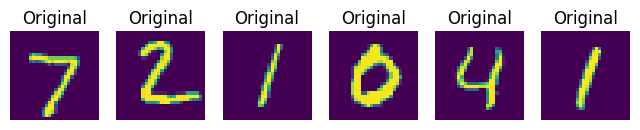

In [39]:
#display original

encoded_img = simple_autoencoder.encoder(x_test).numpy()
decoded_img = simple_autoencoder.decoder(encoded_img).numpy()

n= 6
plt.figure(figsize=(8,4))
for i in range(n):
  #Display original
  ax = plt.subplot(2,n,i+1)
  plt.imshow(x_test[i])
  plt.title("Original")
  plt.axis("off")